Git-repo: https://github.com/oggefaderen/CompSci.git
# Contributions
Lovro: ...

Oskar: ...

Uffe: ...

## Part 1: Mixing Patterns and Assortativity

### Setup: Imports and graph construction

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from collections import defaultdict
import ast
import random
from tqdm import tqdm
import numpy as np

In [2]:
df = pd.read_csv('./D2_temp_papers.csv')
df['author_ids'] = df['author_ids'].apply(ast.literal_eval)

G = nx.Graph()
pair_counts = defaultdict(int)

for author_list in df['author_ids']:
    for i in range(len(author_list)):
        for j in range(i + 1, len(author_list)):
            pair = tuple(sorted([author_list[i].strip(), author_list[j].strip()]))
            pair_counts[pair] += 1

weighted_edgelist = [(a, b, count) for (a, b), count in pair_counts.items()]
G.add_weighted_edges_from(weighted_edgelist)
print(f"Graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

Graph: 466 nodes, 1202 edges


### Load country attributes

In [3]:
authors_df = pd.read_csv('./final_authors.csv')
country_map = dict(zip(authors_df['id'], authors_df['country_code']))

for node in G.nodes():
    G.nodes[node]['country'] = country_map.get(node, None)

countries_assigned = sum(1 for n in G.nodes() if G.nodes[n]['country'] is not None)
print(f"Country assigned to {countries_assigned}/{G.number_of_nodes()} nodes")

Country assigned to 349/466 nodes


## Q1: Country Assortativity Coefficient

Calculate the Assortativity Coefficient for the network based on the country of each node. Implement the calculation using the formula provided during the lecture (Newman equation 2). Do not use the NetworkX implementation.

In [4]:
# Q1: Country assortativity using Newman equation 2 (mixing matrix approach)
# e_ij = fraction of edges connecting country i to country j
# r = (Tr(e) - ||e^2||) / (1 - ||e^2||)

edge_type_counts = defaultdict(int)
total_edges = 0

for u, v in G.edges():
    c_u = G.nodes[u].get('country')
    c_v = G.nodes[v].get('country')
    if c_u is None or c_v is None:
        continue
    # Treat as undirected: always store both orderings
    edge_type_counts[(c_u, c_v)] += 1
    if c_u != c_v:
        edge_type_counts[(c_v, c_u)] += 1
    total_edges += 1

countries = sorted(set(c for (c, _) in edge_type_counts))
M = 2 * total_edges  # denominator: counts each edge in both directions

# e_ij fraction
e = {(c_i, c_j): edge_type_counts.get((c_i, c_j), 0) / M for c_i in countries for c_j in countries}

# Trace and marginal sums
trace_e = sum(e[(c, c)] for c in countries)
a = {c: sum(e[(c, c2)] for c2 in countries) for c in countries}
sum_a_sq = sum(a[c]**2 for c in countries)

original_country_r = (trace_e - sum_a_sq) / (1 - sum_a_sq)
print(f"Country assortativity r = {original_country_r:.4f}")

Country assortativity r = 0.1687


## Q2: Configuration Model

Implement the configuration model using the double edge swap algorithm to generate random networks. Ensure each node retains its original degree but with altered connections.

In [5]:
def configuration_mode_swap(G):
    G_copy = G.copy()
    edges = list(G_copy.edges())
    E = len(edges)
    num_swaps = E * 10
    swaps_done = 0

    while swaps_done < num_swaps:
        e1, e2 = random.sample(edges, 2)
        u, v = e1
        x, y = e2

        # Flip e1 50% of the time to remove directional bias
        if random.random() < 0.5:
            u, v = v, u

        # Ensure swap nodes are distinct
        if u == y or v == x:
            continue

        # Only swap if new edges don't already exist
        if not G_copy.has_edge(u, y) and not G_copy.has_edge(x, v):
            G_copy.remove_edge(*e1)
            G_copy.remove_edge(*e2)
            G_copy.add_edge(u, y)
            G_copy.add_edge(x, v)

            edges.remove(e1)
            edges.remove(e2)
            edges.append((u, y))
            edges.append((x, v))

            swaps_done += 1

    return G_copy

### Degree sequence verification

Verify the configuration model preserves the degree sequence.

In [6]:
original_degrees = dict(G.degree())
G_rand = configuration_mode_swap(G)
rand_degrees = dict(G_rand.degree())
assert original_degrees == rand_degrees, "Degrees don't match!"
print("Degree sequence preserved — configuration model is correct")

Degree sequence preserved — configuration model is correct


## Q3: Country Assortativity in Random Networks

Generate 100 random networks using the configuration model. For each, compute country assortativity and plot the distribution. Compare with the original network to assess whether same-country connections are significantly above chance.

100%|██████████| 100/100 [00:30<00:00,  3.30it/s]


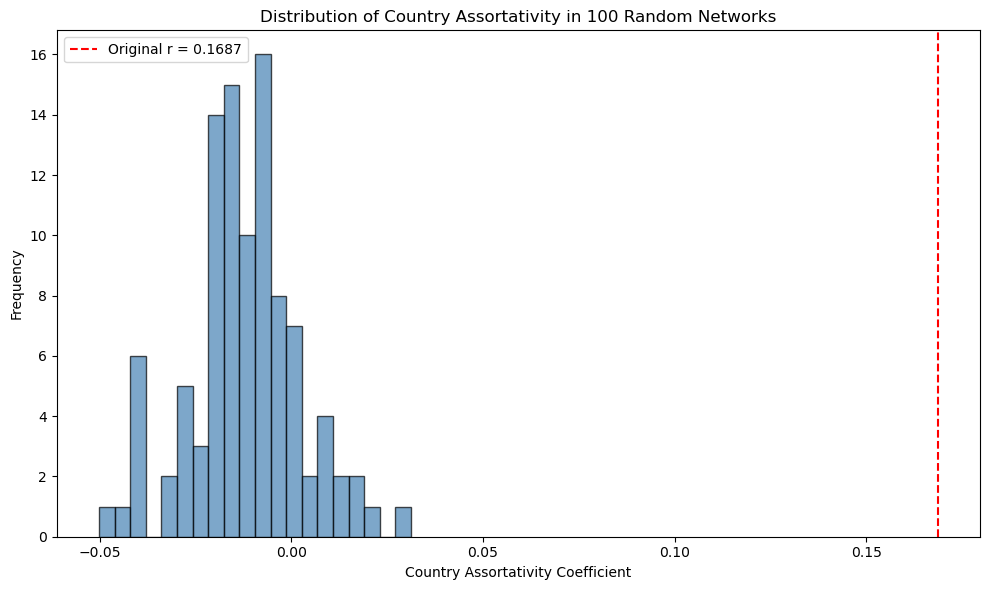

In [7]:
# Q3: Country assortativity distribution over 100 random networks
country_rs_random = []
for i in tqdm(range(100)):
    G_rand = configuration_mode_swap(G)
    # Assign country attributes to the randomized graph nodes
    for node in G_rand.nodes():
        G_rand.nodes[node]['country'] = country_map.get(node, None)
    r_rand = nx.attribute_assortativity_coefficient(G_rand, 'country')
    country_rs_random.append(r_rand)

plt.figure(figsize=(10, 6))
plt.hist(country_rs_random, bins=20, alpha=0.7, color='steelblue', edgecolor='black')
plt.axvline(original_country_r, color='red', linestyle='dashed',
            label=f'Original r = {original_country_r:.4f}')
plt.title('Distribution of Country Assortativity in 100 Random Networks')
plt.xlabel('Country Assortativity Coefficient')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

## Q4: Degree Assortativity

Calculate degree assortativity for the network using the formula discussed in the lecture.

In [8]:
def degree_assortativity(G):
    edges = list(G.edges())
    ku = np.array([G.degree(u, weight='weight') for u, v in edges])
    kv = np.array([G.degree(v, weight='weight') for u, v in edges])

    numerator = np.mean(ku * kv) - np.mean(ku) * np.mean(kv)
    denominator = np.mean(ku**2) - np.mean(ku)**2
    return numerator / denominator if denominator != 0 else 0

original_degree_r = degree_assortativity(G)
print(f"Degree assortativity coefficient: {original_degree_r:.4f}")

Degree assortativity coefficient: -0.0140


## Q5: Degree Assortativity in Random Networks

Compare the network's degree assortativity against 100 random networks generated via the configuration model. Analyze whether high-degree scientists tend to connect with other high-degree scientists.

100%|██████████| 100/100 [00:28<00:00,  3.47it/s]


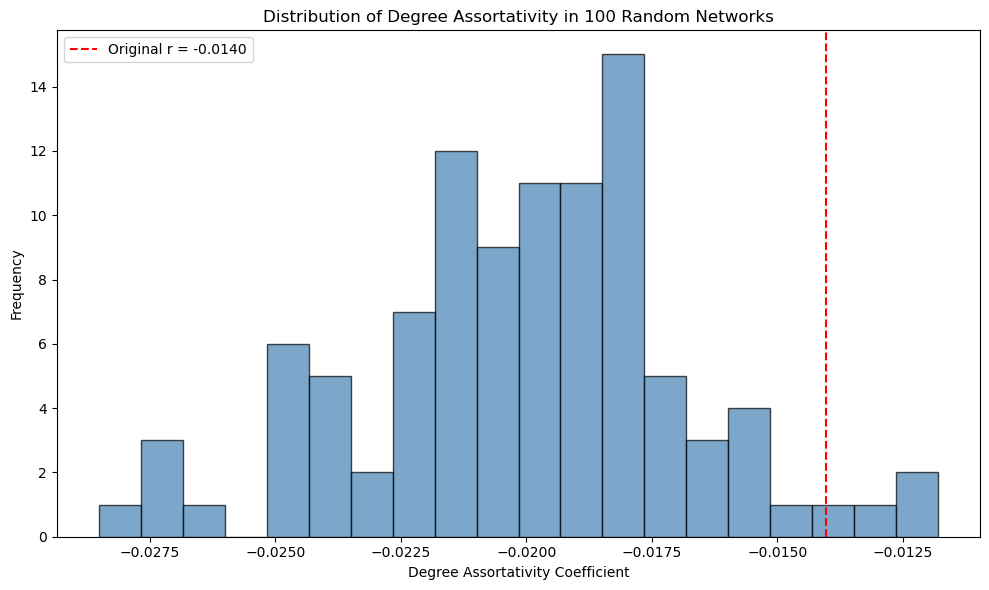

In [9]:
# Q5: Degree assortativity distribution over 100 random networks
degree_rs_random = []
for i in tqdm(range(100)):
    G_rand = configuration_mode_swap(G)
    r_rand = degree_assortativity(G_rand)
    degree_rs_random.append(r_rand)

plt.figure(figsize=(10, 6))
plt.hist(degree_rs_random, bins=20, alpha=0.7, color='steelblue', edgecolor='black')
plt.axvline(original_degree_r, color='red', linestyle='dashed',
            label=f'Original r = {original_degree_r:.4f}')
plt.title('Distribution of Degree Assortativity in 100 Random Networks')
plt.xlabel('Degree Assortativity Coefficient')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

## Part 5: Reflection Questions

### Assortativity by degree. Were the results of the degree assortativity in line with your expectations? Why or why not?

The degree assortativity of the original network (`r = [original_degree_r]`) sits at the right tail of the null distribution produced by 100 configuration-model randomizations, which ranges roughly from `[min_degree_rs_random]` to `[max_degree_rs_random]`. This means the original network is less disassortative than most random networks that share its degree sequence.

Two observations follow. First, the configuration model alone produces networks that are more disassortative than the real one: preserving the degree sequence structurally forces hubs to connect with low-degree nodes, since there are few other hubs available. Second, the real network departs from this null in the assortative direction, indicating a weak but genuine tendency for high-degree authors to collaborate with each other — beyond what the degree sequence predicts. This assortative pull likely reflects social mechanisms such as shared institutional affiliations or conference co-attendance among prominent researchers. The position of the original value at the tail of the null distribution makes this departure statistically notable.

### Edge flipping. In the process of implementing the configuration model, you were instructed to flip the edges (e.g., changing e_1 from (u,v) to (v,u)) 50% of the time. Why do you think this step is included?

The 50% flip is included to remove directional bias introduced by NetworkX's edge ordering. When `list(G.edges())` is called, NetworkX returns each edge `(u, v)` in a consistent internal order determined by node insertion sequence — not randomly. Without the flip, every swap produces new edges `(u, y)` and `(x, v)`, where `u` and `x` are always the "first" nodes from their respective original edges. Over `E × 10` swaps, this systematically favours certain nodes appearing on the source side of new connections, skewing the degree distribution of the randomized network.

By flipping `(u, v)` to `(v, u)` with probability 0.5, the assignment of which endpoint gets paired with a new partner is randomized. Over many swaps the pairing becomes symmetric and unbiased. Without this step, the 100 randomized networks would not be genuinely exchangeable with the original, and the null distribution would be an artefact of memory ordering rather than a true structural baseline.

### Distribution of assortativity in random networks. Describe the distribution of degree assortativity values you observed for the random networks. Was the distribution pattern expected? Discuss how the nature of random network generation (specifically, the configuration model and edge flipping) might influence this distribution and whether it aligns with theoretical expectations.

The degree assortativity values across 100 randomized networks form a roughly bell-shaped distribution centred around `[mean_degree_rs_random]`, spanning approximately `[min_degree_rs_random]` to `[max_degree_rs_random]`. The spread is narrow relative to the centre, with most values concentrated in a range of width approximately `[range_degree_rs_random]`.

Both the negative centre and the narrow spread are expected. Networks with heterogeneous degree distributions — where a small number of nodes hold a disproportionate share of connections — are structurally disassortative under random wiring: hubs cannot consistently connect with other hubs because there are too few of them. The configuration model enforces exactly this constraint by fixing the degree sequence across all 100 realizations, so every network starts with the same structural budget. The resulting narrow distribution reflects sampling variance within a tightly constrained null model, not genuine diversity in mixing patterns. The original network's value (`r = [original_degree_r]`) at the right tail is therefore the meaningful signal: the real collaboration network is measurably less disassortative than pure chance given its degree sequence.

## Part 2: TF-IDF Analysis

In [ ]:
import nltk
import ast
import string
import math
from collections import Counter
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import pandas as pd

nltk.download('punkt_tab')
nltk.download('stopwords')

In [ ]:
# Load community assignments
community_df = pd.read_csv('./author_communities.csv')

# Load papers with abstracts
abstracts_df = pd.read_csv('./D2_temp_papers.csv')
abstracts_df['author_ids'] = abstracts_df['author_ids'].apply(ast.literal_eval)

# Explode so each row has one author
exploded = abstracts_df.explode('author_ids')
exploded['author_ids'] = exploded['author_ids'].str.strip()

# Merge with community assignments
merged = exploded.merge(community_df, left_on='author_ids', right_on='author_id')

# Helper: convert abstract inverted index to plain text
def inverted_index_to_text(inv_idx_str):
    if pd.isna(inv_idx_str):
        return ''
    inv_idx = ast.literal_eval(inv_idx_str)
    words = [''] * (max(max(pos) for pos in inv_idx.values()) + 1)
    for word, positions in inv_idx.items():
        for pos in positions:
            words[pos] = word
    return ' '.join(words)

# Convert abstracts to text
merged['text'] = merged['abstract_inverted_index'].apply(inverted_index_to_text)

## Q2: Create Community Token Documents

For each community, create a large token document by combining all paper abstracts written by authors in that community. Use pandas `groupby` and `apply` to aggregate tokens per community.

In [ ]:
stop_words = set(stopwords.words('english'))

def tokenize(text):
    tokens = word_tokenize(text.lower())
    return [w for w in tokens if w not in stop_words and w not in string.punctuation]

# Group by community — combine all tokens into one document per community
# Uses pandas groupby + apply (explode already done above)
community_docs = (
    merged.groupby('community')['text']
    .apply(lambda texts: tokenize(' '.join(texts)))
    .to_dict()
)

for comm in sorted(community_docs.keys()):
    print(f'Community {comm}: {len(community_docs[comm])} tokens')